In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
import copy
import pickle
import shap
from models import *
from utilities import *
import warnings
warnings.filterwarnings('ignore')

In [41]:
##########################################################################################################

In [42]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Eager mode:", tf.executing_eagerly())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.15.0
Eager mode: True
GPUs: []


In [43]:
# shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [44]:
################### data import ###############

In [45]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
data_copy = data_copy.fillna(0)
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [46]:
hu = read_sas('../data/Apply_MI_Zheng_2023_01/hu.sas7bdat')

In [47]:
data_copy_nohu = data_copy[data_copy['HU_status']==0]
data_copy_hu = data_copy[data_copy['HU_status']!=0]

In [48]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)
ba_copy = ba_copy.fillna(0)

In [49]:
feature_dy = data_copy_nohu.drop(['HU_status','Id_encoded','SCCRIP_ID', 'date'],axis=1).columns
feature_ba = ba_copy.drop(['Id_encoded'], axis=1).columns

In [50]:
################ data process ##################

In [51]:
seq_length = 5

In [52]:
############ no-HU 

sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_nohu, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

(X_train_nohu,X_val_nohu,X_test_nohu,
            X_bg_train_nohu,X_bg_val_nohu,X_bg_test_nohu,
            dt_train_nohu, dt_val_nohu, dt_test_nohu, 
            y_train_nohu,y_val_nohu,y_test_nohu,
            ls_train_nohu, ls_val_nohu, ls_test_nohu,
            seq_map_train_nohu, seq_map_val_nohu, seq_map_test_nohu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)

In [53]:
############ HU 

sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_hu, ba_copy, seq_length, mapping_dict)
sequences_copy_h, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy_h, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

(X_train_hu,X_val_hu,X_test_hu,
            X_bg_train_hu,X_bg_val_hu,X_bg_test_hu,
            dt_train_hu, dt_val_hu, dt_test_hu, 
            y_train_hu,y_val_hu,y_test_hu,
            ls_train_hu, ls_val_hu, ls_test_hu,
            seq_map_train_hu, seq_map_val_hu, seq_map_test_hu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)

In [54]:
# Initialize the model class
combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train_hu.shape[2]), bg_features=int(X_bg_train_hu.shape[2]))

Model input shapes: (None, 5, 786) (None, 1, 23) (None, 1, 1)
Model: "CombinedLSTMModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_bg (InputLayer)       [(None, 1, 23)]              0         []                            
                                                                                                  
 input_dt (InputLayer)       [(None, 1, 1)]               0         []                            
                                                                                                  
 input_seq (InputLayer)      [(None, 5, 786)]             0         []                            
                                                                                                  
 bg_plus_dt (Concatenate)    (None, 1, 24)                0         ['input_bg[0][0]',            
                    

In [55]:
# Train the model
history = combined_model.train(
    X_train_hu, X_bg_train_hu, dt_train_hu, y_train_hu,
    X_val_hu,   X_bg_val_hu,   dt_val_hu,   y_val_hu,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/T_best.h5"
)

Epoch 1/20
192/198 [============================>.] - ETA: 0s - loss: 79.3841 - mean_absolute_error: 5.7373
Epoch 1: val_loss improved from inf to 19.79758, saving model to ../results/models/T_best2.h5
198/198 [==============================] - 3s 7ms/step - loss: 77.4303 - mean_absolute_error: 5.6482 - val_loss: 19.7976 - val_mean_absolute_error: 3.1086
Epoch 2/20
193/198 [============================>.] - ETA: 0s - loss: 14.3301 - mean_absolute_error: 2.6697
Epoch 2: val_loss improved from 19.79758 to 16.94567, saving model to ../results/models/T_best2.h5
198/198 [==============================] - 1s 5ms/step - loss: 14.3647 - mean_absolute_error: 2.6726 - val_loss: 16.9457 - val_mean_absolute_error: 2.8667
Epoch 3/20
193/198 [============================>.] - ETA: 0s - loss: 11.0191 - mean_absolute_error: 2.3240
Epoch 3: val_loss did not improve from 16.94567
198/198 [==============================] - 1s 5ms/step - loss: 11.0278 - mean_absolute_error: 2.3298 - val_loss: 18.6900 - va

In [56]:
combined_model.save("../results/models/T_best.h5")
combined_model.load("../results/models/T_best.h5")

In [57]:
figure_dir = '../results/figures/tmodel/'
ensure_directory_exists(figure_dir)

Directory '../results/figures/tmodel/' already exists.


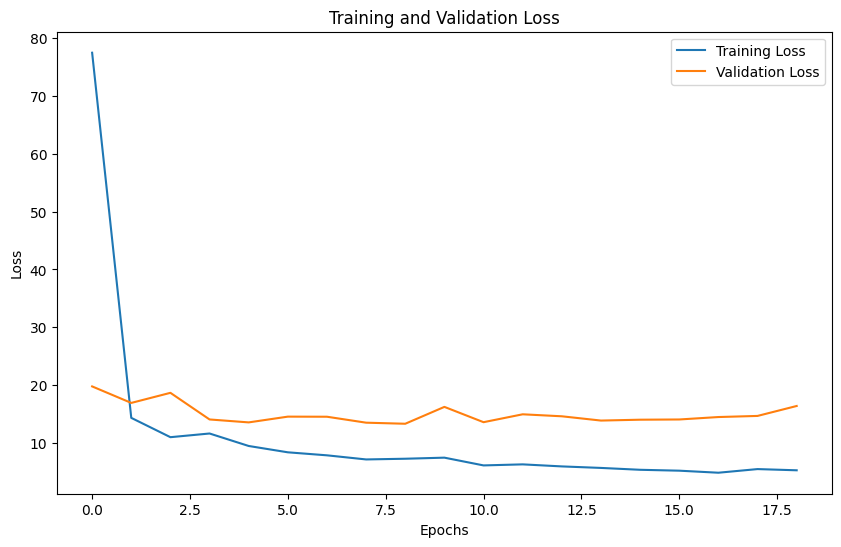

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# plt.savefig(figure_dir + 'LOSS.png')
plt.show()

In [59]:
y_pred_hu = combined_model.predict(X_test_hu, X_bg_test_hu, dt_test_hu)
y_pred_nohu = combined_model.predict(X_test_nohu, X_bg_test_nohu, dt_test_nohu)

29/29 [==============================] - 0s 1ms/step


In [60]:
from scipy.stats import pearsonr
mse = mean_squared_error(y_test_hu.flatten(), y_pred_hu.flatten())
mae = mean_absolute_error(y_test_hu.flatten(), y_pred_hu.flatten())
r2_hu = r2_score(y_test_hu.flatten(), y_pred_hu.flatten())
r_hu, _  = pearsonr(y_test_hu.flatten(), y_pred_hu.flatten())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2_hu:.4f}")
print(f"r: {r_hu:.4f}")

Mean Squared Error: 13.1494
Mean Absolute Error: 2.5928
R^2 Score: 0.8452
r: 0.9212


In [61]:
mse = mean_squared_error(y_test_nohu.flatten(), y_pred_nohu.flatten())
mae = mean_absolute_error(y_test_nohu.flatten(), y_pred_nohu.flatten())
r2_nohu = r2_score(y_test_nohu.flatten(), y_pred_nohu.flatten())
r_nohu, _ = pearsonr(y_test_nohu.flatten(), y_pred_nohu.flatten())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2_nohu:.4f}")
print(f"r: {r_nohu:.4f}")

Mean Squared Error: 94.6316
Mean Absolute Error: 8.8455
R^2 Score: -0.7550
r: 0.8335


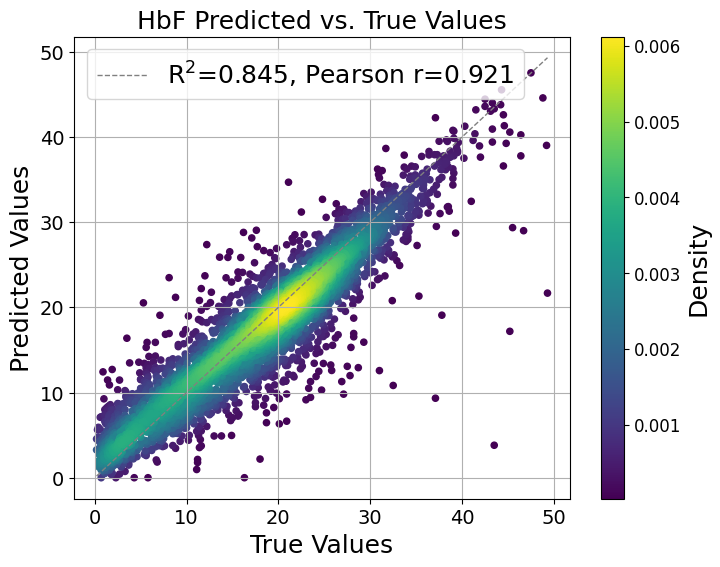

In [62]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_grey", ["#B3B3B3", "#4D4D4D"])

from scipy.stats import gaussian_kde, linregress

y_test_hu = y_test_hu.reshape(y_test_hu.shape[0])
y_pred_hu = y_pred_hu.reshape(y_pred_hu.shape[0])
xy = np.vstack([y_test_hu, y_pred_hu])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test_hu, y_pred_hu, z = y_test_hu[idx], y_pred_hu[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test_hu,
    y_pred_hu,
    c=z,
    cmap='viridis',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test_hu.min(), y_test_hu.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'R$^2$={r2_hu:.3f}, Pearson r={r_hu:.3f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
# plt.xlim([0,80])
# plt.ylim([0,80])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('HbF Predicted vs. True Values', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
# plt.savefig(figure_dir+'dot_dot_hu2.pdf')

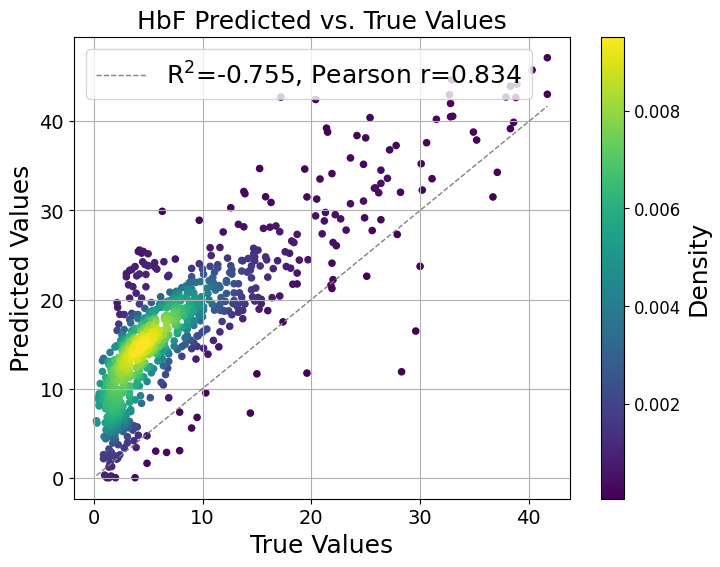

In [63]:
y_test_nohu = y_test_nohu.reshape(y_test_nohu.shape[0])
y_pred_nohu = y_pred_nohu.reshape(y_pred_nohu.shape[0])
xy = np.vstack([y_test_nohu, y_pred_nohu])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test_nohu, y_pred_nohu, z = y_test_nohu[idx], y_pred_nohu[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test_nohu,
    y_pred_nohu,
    c=z,
    cmap='viridis',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test_nohu.min(), y_test_nohu.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'R$^2$={r2_nohu:.3f}, Pearson r={r_nohu:.3f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
# plt.xlim([0,80])
# plt.ylim([0,80])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('HbF Predicted vs. True Values', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
# plt.savefig(figure_dir+'dot_dot_nohu2.pdf')

In [64]:
####################################################

In [66]:
r2 = []
shap_impact = []
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_hu, ba_copy, seq_length, mapping_dict)
sequences_copy_h, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy_h, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

while len(shap_impact) < 20:
    print(len(shap_impact))
    (X_train_hu,X_val_hu,X_test_hu,
                X_bg_train_hu,X_bg_val_hu,X_bg_test_hu,
                dt_train_hu, dt_val_hu, dt_test_hu, 
                y_train_hu,y_val_hu,y_test_hu,
                ls_train_hu, ls_val_hu, ls_test_hu,
                seq_map_train_hu, seq_map_val_hu, seq_map_test_hu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)
    
    combined_model_l = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train_hu.shape[2]), bg_features=int(X_bg_train_hu.shape[2]), summary=False)
    
    history = combined_model_l.train(
    X_train_hu, X_bg_train_hu, dt_train_hu, y_train_hu,
    X_val_hu,   X_bg_val_hu,   dt_val_hu,   y_val_hu,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/T_best2_loop.h5")
    y_pred_hu = combined_model_l.predict(X_test_hu, X_bg_test_hu, dt_test_hu)
    r2_hu = r2_score(y_test_hu.flatten(), y_pred_hu.flatten())
    if r2_hu > 0:
        r2.append(r2_hu)

        explainer = shap.GradientExplainer(combined_model_l.model, [X_test_hu, X_bg_test_hu, dt_test_hu])
        shap_values = explainer.shap_values([X_test_hu, X_bg_test_hu, dt_test_hu])

        shap_val_d = []
        train_d = []
        
        for i in range (5):
            shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
            train_d.append(pd.DataFrame(X_test_hu[:,i,:],columns=feature_dy))
            
        shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
        train_b = pd.DataFrame(X_bg_test_hu[:,0,:], columns=feature_ba)

        impact_dy = []

        for i in range(5):
            im = ABS_SHAP(shap_val_d[i], train_d[i])
            impact_dy.append(im)
            
        impact_ba = ABS_SHAP(shap_val_b, train_b)
        shap_impact.append((impact_dy, impact_ba))

0
Epoch 1/20
192/199 [===========================>..] - ETA: 0s - loss: 67.8959 - mean_absolute_error: 5.5881
Epoch 1: val_loss improved from inf to 55.26688, saving model to ../results/models/T_best2_loop.h5
199/199 [==============================] - 3s 7ms/step - loss: 66.1406 - mean_absolute_error: 5.5006 - val_loss: 55.2669 - val_mean_absolute_error: 4.3579
Epoch 2/20
193/199 [============================>.] - ETA: 0s - loss: 16.1671 - mean_absolute_error: 2.8891
Epoch 2: val_loss did not improve from 55.26688
199/199 [==============================] - 1s 5ms/step - loss: 16.1368 - mean_absolute_error: 2.8885 - val_loss: 56.8982 - val_mean_absolute_error: 4.1296
Epoch 3/20
193/199 [============================>.] - ETA: 0s - loss: 10.3040 - mean_absolute_error: 2.2848
Epoch 3: val_loss did not improve from 55.26688
199/199 [==============================] - 1s 5ms/step - loss: 10.2811 - mean_absolute_error: 2.2842 - val_loss: 56.2534 - val_mean_absolute_error: 4.0311
Epoch 4/20
193

In [67]:
with open('../results/data/tmodel/shap_impact_list.pkl','wb') as f:
    pickle.dump(shap_impact,f)

In [ ]:
with open('../results/data/tmodel/r2_Tmodel.pkl','wb') as f:
    pickle.dump(r2,f)

In [68]:
#########################################

In [69]:
# combined_model.load("../results/models/T_best2.h5")
# explainer = shap.DeepExplainer(combined_model.model, [X_test_hu, X_bg_test_hu, dt_test_hu])
# shap_values = explainer.shap_values([X_test_hu, X_bg_test_hu, dt_test_hu])

In [70]:
# shap_val_d = []
# train_d = []

# for i in range (5):
#     shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
#     train_d.append(pd.DataFrame(X_test_hu[:,i,:],columns=feature_dy))
    
# shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
# train_b = pd.DataFrame(X_bg_test_hu[:,0,:], columns=feature_ba)

In [71]:
# impact_dy = []

# for i in range(5):
#     im = ABS_SHAP(shap_val_d[i], train_d[i])
#     impact_dy.append(im)
    
# impact_ba = ABS_SHAP(shap_val_b, train_b)

In [72]:
# with open('../results/data/tmodel/shap_values_Hu.pkl', 'wb') as f:
#     pickle.dump(shap_values, f)
# with open('../results/data/tmodel/shap_impact_hu.pkl', 'wb') as f:
#     pickle.dump((impact_dy,impact_ba), f)